C:\Users\tayyi\AppData\Local\Temp\ipykernel_9984\3603274134.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="classification", data=data, palette={"ckd": "tomato", "notckd": "blue"})
C:\Users\tayyi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


*Accuracy score for LR: 85.0
              precision    recall  f1-score   support

           0       0.85      0.89      0.87        44
           1       0.85      0.81      0.83        36

    accuracy                           0.85        80
   macro avg       0.85      0.85      0.85        80
weighted avg       0.85      0.85      0.85        80

*Accuracy score for RF: 88.75
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        47
           1       0.85      0.88      0.87        33

    accuracy                           0.89        80
   macro avg       0.88      0.89      0.88        80
weighted avg       0.89      0.89      0.89        80

*Accuracy score for SVM: 83.75
*Accuracy score for KNN: 87.5
*Accuracy score for GNB: 76.25


C:\Users\tayyi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\tayyi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


*Accuracy score for Voting Classifier: 88.75


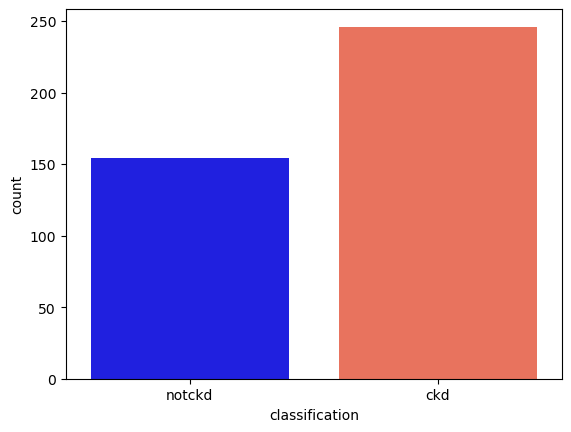

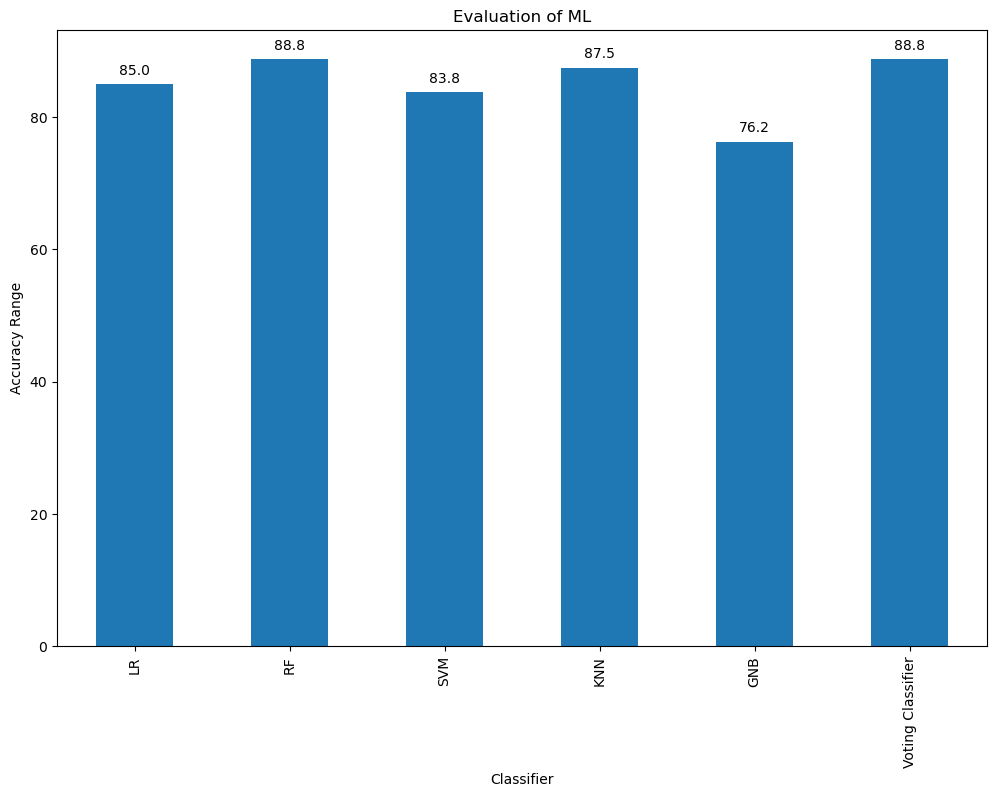

In [2]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Load data
data = pd.read_csv('C:/Users/tayyi/Downloads/datset.csv')

# Mapping categorical values to numeric
data['rbc'] = data.rbc.map({'normal': 0.0, 'abnormal': 1.0})
data['pc'] = data.pc.map({'normal': 0.0, 'abnormal': 1.0})
data['pcc'] = data.pcc.map({'notpresent': 0.0, 'present': 1.0})
data['ba'] = data.ba.map({'notpresent': 0.0, 'present': 1.0})
data['htn'] = data.htn.map({'no': 0.0, 'yes': 1.0})
data['dm'] = data.dm.map({'no': 0.0, 'yes': 1.0})
data['cad'] = data.cad.map({'no': 0.0, 'yes': 1.0})
data['appet'] = data.appet.map({'good': 0.0, 'poor': 1.0})
data['pe'] = data.pe.map({'no': 0.0, 'yes': 1.0})
data['ane'] = data.ane.map({'no': 0.0, 'yes': 1.0})

# Plot class distribution
sns.countplot(x="classification", data=data, palette={"ckd": "tomato", "notckd": "blue"})

# Imputation of missing values
imputer = KNNImputer(n_neighbors=2)
columns_to_impute = ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'htn', 'bu', 'dm', 'sc', 'cad', 'sod', 'appet', 'pot', 'pe', 'hemo', 'ane']
data_filled = imputer.fit_transform(data[columns_to_impute])

# Encode labels
label_encoder = preprocessing.LabelEncoder()
data['classification'] = label_encoder.fit_transform(data['classification'])
y = data['classification'].values

# Split the data
x_train, x_test, y_train, y_test = train_test_split(data_filled, y, test_size=0.2)

# Logistic Regression
lr = LogisticRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
LR_acc = lr.score(x_test, y_test) * 100
print("*Accuracy score for LR:", LR_acc)
print(classification_report(y_pred, y_test))

# Random Forest
RF = RandomForestClassifier()
RF.fit(x_train, y_train)
predictions = RF.predict(x_test)
RF_acc = accuracy_score(y_test, predictions) * 100
print("*Accuracy score for RF:", RF_acc)
print(classification_report(predictions, y_test))

# SVM
SVM = SVC()
SVM.fit(x_train, y_train)
predictions = SVM.predict(x_test)
SVM_Acc = accuracy_score(y_test, predictions) * 100
print("*Accuracy score for SVM:", SVM_Acc)

# KNN
KNN = KNeighborsClassifier()
KNN.fit(x_train, y_train)
predictions = KNN.predict(x_test)
KNN_Acc = accuracy_score(y_test, predictions) * 100
print("*Accuracy score for KNN:", KNN_Acc)

# Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(x_train, y_train)
y_pred = gnb.predict(x_test)
gnb_acc = accuracy_score(y_test, y_pred) * 100
print("*Accuracy score for GNB:", gnb_acc)

# Voting Classifier
estimator = []
estimator.append(('LR', LogisticRegression(solver='lbfgs', multi_class='multinomial', max_iter=200)))
estimator.append(('RFC', RandomForestClassifier()))
estimator.append(('DTC', DecisionTreeClassifier()))
vot_hard = VotingClassifier(estimators=estimator, voting='hard')
vot_hard.fit(x_train, y_train)
predictions = vot_hard.predict(x_test)
vot_acc = accuracy_score(y_test, predictions) * 100
print("*Accuracy score for Voting Classifier:", vot_acc)

# Plotting accuracies
frequencies = [LR_acc, RF_acc, SVM_Acc, KNN_Acc, gnb_acc, vot_acc]
x_labels = ['LR', 'RF', 'SVM', 'KNN', 'GNB', 'Voting Classifier']
freq_series = pd.Series(frequencies)

plt.figure(figsize=(12, 8))
ax = freq_series.plot(kind='bar')
ax.set_title('Evaluation of ML')
ax.set_xlabel('Classifier')
ax.set_ylabel('Accuracy Range')
ax.set_xticklabels(x_labels)

# Add value labels on bars
def add_value_labels(ax, spacing=5):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        va = 'bottom'
        if y_value < 0:
            space *= -1
            va = 'top'
        label = "{:.1f}".format(y_value)
        ax.annotate(label,
                    (x_value, y_value),
                    xytext=(0, space),
                    textcoords="offset points",
                    ha='center', va=va)

add_value_labels(ax)
plt.show()
